# DM2026 ML Lab 2: NER

Выполнили студенты 25ИАД:
- Ерёменко Данил
- Кудасов Максим

В данной задаче требуется с помощью разных алгоритмов/моделей получить сущности в тексте, которые в дальнейшем можно распределить на несколько категорий, а конкретно:
- ORGANIZATION - Bilderberg Club
- PERSON - Sergey Druzhko, Natalia Marine Infantry
- LOCATION - Murray River, Mount Everest
- DATE - June, 2007-08-01
- TIME - two fifty a m, 1:30 p.m.
- MONEY - 175 million Canadian Dollars, GBP 10.40
- PERCENT - twenty pct, 18.75 %
- FACILITY - Washington Monument, Stonehenge
- GPE - South East Asia, Nizhny Novgorod region

Для категорий в дальнейшем будут применять сокращения.

## Подготовка к загрузке данных

In [29]:
import os
import sys
import json
import random
import warnings
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import HTML

warnings.filterwarnings("ignore")

In [3]:
if os.path.basename(os.getcwd()) == "notebooks":
    PROJECT_ROOT = os.path.abspath("..")
else:
    PROJECT_ROOT = os.getcwd()

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

Здесь мы решили для читаемости раскидать весь код по файлам, чтобы в ноутбуке можно было проследить общий пайплайн того, как работает система.

In [4]:
from src.preprocess import (
    ID2TAG,
    TAG2ID,
    load_csv,
    build_sentence_examples,
    train_valid_split_balanced,
    statistical_oversample,
)

from src.metrics import entity_level_prf1
from src.crf import CRFNER
from src.tf import TransformerNER, TransformerConfig
from src.entity import EntityStore
from src.entity_ingest import ingest_examples
from src.visualize import highlight_entities_html, plot_category_wordcloud

In [5]:
DATA_DIR = os.path.join(PROJECT_ROOT, "data")
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "outputs")
FIG_DIR = os.path.join(OUTPUT_DIR, "figures")
MODEL_DIR = os.path.join(OUTPUT_DIR, "models")

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

TRAIN_PATH = os.path.join(DATA_DIR, "train.csv")
TEST_PATH = os.path.join(DATA_DIR, "test.csv")

In [6]:
TRAIN_CRF = False
TRAIN_TF = False
SHOW_PROGRESS = True

CRF_CHECKPOINT = os.path.join(MODEL_DIR, "crf_ner.joblib")
TF_CHECKPOINT = os.path.join(MODEL_DIR, "distilbert_ner")

Сначала займёмся предобработкой данных.

Так как у нас формат данных неудобен, в том числе для чтения, поэтому его надо бы сначала преобразовать в примеры для обучения, чтобы наши модели его могли понять. Для этого мы используем отдельный класс `SentenceExample`, где у нас будет в более подходящем формате раскиданы данные из таблицы. В дальнейшем, нам нужно из этих `SentenceExample` получить готовые `Entity`, которые мы потом будем исопльзовать в базе данных.

In [7]:
train_df = load_csv(TRAIN_PATH, has_labels=True)
test_df = load_csv(TEST_PATH, has_labels=False)

train_examples = build_sentence_examples(train_df, has_labels=True)
test_examples = build_sentence_examples(test_df, has_labels=False)

print(f"Numer of rows for train: {len(train_df)}, for test: {len(test_df)}")
print(f"Number of sentences (examples) for train: {len(train_examples)}, test: {len(test_examples)}")
display(train_df.head(10))
display(test_examples[:3])

Numer of rows for train: 839364, for test: 209211
Number of sentences (examples) for train: 38367, test: 9592


,row_id,Sentence_id,Word,POS,Tag,Tag_str
0,0,1,Thousands,NNS,0,O
1,1,1,of,IN,0,O
2,2,1,demonstrators,NNS,0,O
3,3,1,have,VBP,0,O
4,4,1,marched,VBN,0,O
5,5,1,through,IN,0,O
6,6,1,London,NNP,7,B-geo
7,7,1,to,TO,0,O
8,8,1,protest,VB,0,O
9,9,1,the,DT,0,O


[SentenceExample(sentence_id=11, row_ids=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11], tokens=['The', 'step', 'will', 'allow', 'the', 'facility', 'to', 'operate', 'at', 'full', 'capacity', '.'], pos_tags=['DT', 'NN', 'MD', 'VB', 'DT', 'NN', 'TO', 'VB', 'IN', 'JJ', 'NN', '.'], ner_tags=None),
 SentenceExample(sentence_id=16, row_ids=[12, 13, 14, 15, 16, 17, 18, 19, 20, 21], tokens=['The', 'German', 'firm', 'works', 'as', 'a', 'sub-contractor', 'for', 'Shell', '.'], pos_tags=['DT', 'JJ', 'NN', 'VBZ', 'IN', 'DT', 'NN', 'IN', 'NNP', '.'], ner_tags=None),
 SentenceExample(sentence_id=18, row_ids=[22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55], tokens=['Poor', 'residents', 'often', 'complain', 'they', 'have', 'been', 'cheated', 'out', 'of', 'the', 'huge', 'riches', 'extracted', 'from', 'their', 'tribal', 'lands', '-', 'where', 'the', 'bulk', 'of', 'Nigeria', "'s", '2.3', 'million', 'barrels', 'of', 'petroleum'

Далее рассмотрим, сколько каждого из тегов в формате CONLL2003 у нас есть, чтобы выявить возможный дисбаланс классов.

In [8]:
tag_counts = train_df["Tag_str"].value_counts()
tag_counts

Tag_str
O        710524
B-geo     30338
B-tim     16239
B-org     16140
I-per     13903
B-per     13573
I-org     13462
B-gpe     12662
I-geo      5987
I-tim      5152
B-art       321
B-eve       252
I-art       241
I-eve       206
B-nat       164
I-gpe       155
I-nat        45
Name: count, dtype: int64

Есть очень выраженный дисбаланс классов, который нам в дальнейшем нужно будет решить. Для CRF модели это большой роли не сыграет, а вот для BERT уже может, поэтому нужно попробовать сначала запустить без аугментаций, а потом попробовать их.

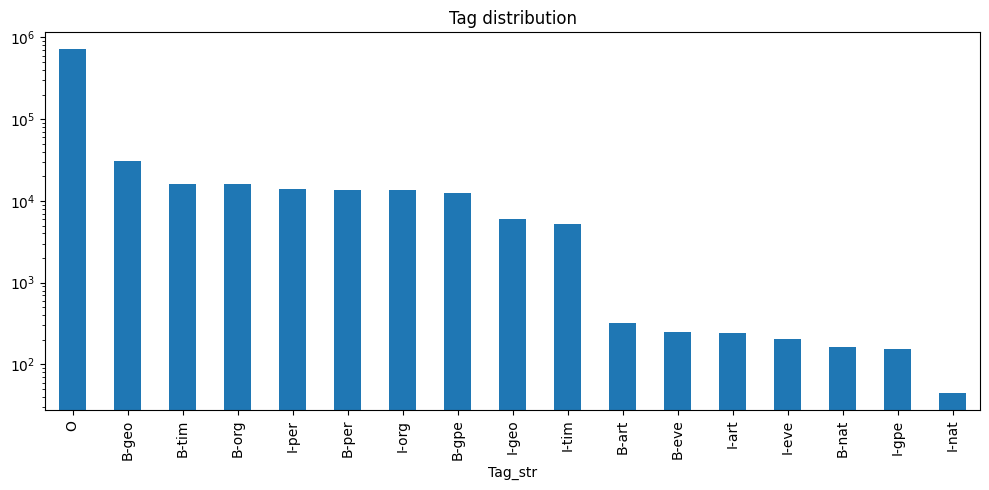

In [9]:
plt.figure(figsize=(10, 5))
tag_counts.plot(kind="bar")
plt.title("Tag distribution")
plt.yscale('log')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "tag_distribution.png"))
plt.show()

Важно подметить, что шкала логарифмическая, так как в ином случае было бы тяжелее увидеть реальное распределение данных по объектам.

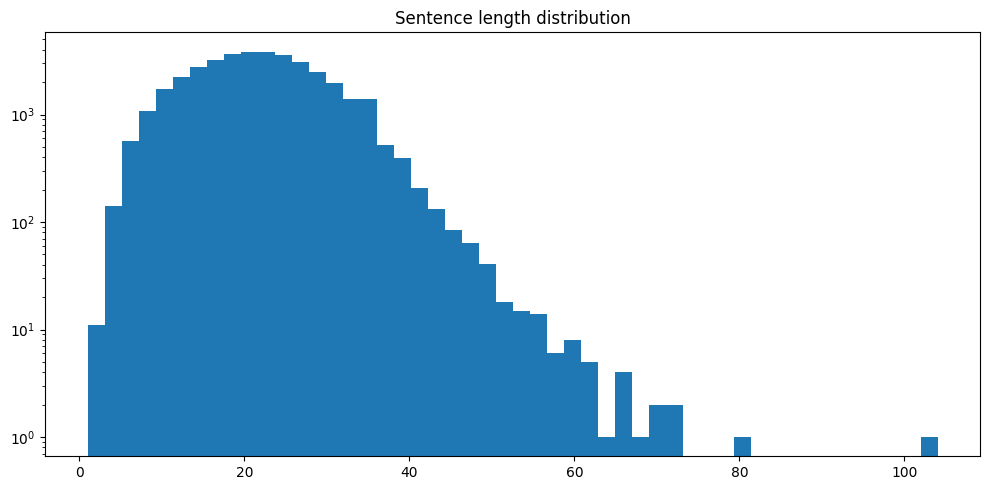

In [10]:
sentence_lengths = [len(ex.tokens) for ex in train_examples]

plt.figure(figsize=(10, 5))
plt.hist(sentence_lengths, bins=50)
plt.yscale('log')
plt.title("Sentence length distribution")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "sentence_length_distribution.png"))
plt.show()

Здесь мы можем наблюдать, что у нас длина самого большого предложения не больше 120, в дальнейшем это нам понадобится для подбора параметров для берта.

Также видно, что сами предложения сконцентрированы в районе от 0 до 70 слов с пиком в 20.

In [11]:
train_split, valid_split = train_valid_split_balanced(
    train_examples,
    valid_size=0.2,
    random_state=42,
)

len(train_split), len(valid_split)

(30692, 7675)

## Эксперименты

### Эксперимент 1 (без аугментации)

In [12]:
crf_model = CRFNER(show_progress=SHOW_PROGRESS)

if TRAIN_CRF or not os.path.exists(CRF_CHECKPOINT):
    print("Training CRF...")
    crf_model.fit(train_split)
    crf_model.save(CRF_CHECKPOINT)
else:
    print("Loading CRF from checkpoint...")
    crf_model.load(CRF_CHECKPOINT)

crf_pred = crf_model.predict(valid_split)
y_true = [x.ner_tags for x in valid_split]

crf_scores = entity_level_prf1(y_true, crf_pred)
crf_scores

Loading CRF from checkpoint...


CRF predict features:   0%|          | 0/7675 [00:00<?, ?it/s]

{'precision': 0.8540929329832173,
 'recall': 0.8399483523269522,
 'f1': 0.8469615918032323,
 'tp': 14962,
 'fp': 2556,
 'fn': 2851}

Можем наблюдать, что CRF модель получила очень неплохие результаты на наших данных, которые можно в дальнейшем использовать для соревнования.

Также проводился перебор других параметров, в том числе попытка сделать аугментацию данных, но метрики от этого значительно не менялись, может быть на 2%, так что модель устойчива к качеству и количеству наших данных.

In [13]:
# tf_config = TransformerConfig(
#     model_name="distilbert-base-cased",
#     max_length=128,
#     output_dir=TF_CHECKPOINT,
#     learning_rate=2e-5,
#     train_batch_size=16,
#     eval_batch_size=16,
#     num_train_epochs=3,
#     show_progress=SHOW_PROGRESS,
# )

tf_config = TransformerConfig(
    model_name="bert-base-cased",
    max_length=128,
    output_dir=TF_CHECKPOINT,
    learning_rate=2e-5,
    train_batch_size=16,
    eval_batch_size=16,
    num_train_epochs=4,
    show_progress=SHOW_PROGRESS,
)

tf_model = TransformerNER(tf_config)

checkpoint_exists = os.path.exists(TF_CHECKPOINT) and os.path.exists(os.path.join(TF_CHECKPOINT, "config.json"))

if TRAIN_TF or not checkpoint_exists:
    print("Training transformer...")
    tf_model.fit(train_split, valid_split, do_train=True)
else:
    print("Loading transformer from checkpoint...")
    tf_model.load(TF_CHECKPOINT)

tf_pred = tf_model.predict(valid_split)
tf_scores = entity_level_prf1(y_true, tf_pred)
tf_scores

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: bert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized beca

Loading transformer from checkpoint...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Transformer predict:   0%|          | 0/7675 [00:00<?, ?it/s]

{'precision': 0.8360057503041026,
 'recall': 0.8488182787851569,
 'f1': 0.8423632970277724,
 'tp': 15120,
 'fp': 2966,
 'fn': 2693}

### Эксперимент 2 (с аугментацией)

Теперь попробуем обучить модель с аугментацией, может быть это нам поднимет качество.

In [14]:
train_split_aug = statistical_oversample(train_split, max_duplicates=15)
print(len(train_split_aug))

51721


In [17]:
NEW_TF_CHECKPOINT = TF_CHECKPOINT + "-aug"

tf_config_aug = TransformerConfig(
    model_name="bert-base-cased",
    max_length=128,
    output_dir=NEW_TF_CHECKPOINT,
    learning_rate=1e-6,
    train_batch_size=16,
    eval_batch_size=16,
    num_train_epochs=4,
    show_progress=SHOW_PROGRESS,
)

tf_model_aug = TransformerNER(tf_config_aug)

checkpoint_exists = os.path.exists(NEW_TF_CHECKPOINT) and os.path.exists(os.path.join(NEW_TF_CHECKPOINT, "config.json"))

if TRAIN_TF or not checkpoint_exists:
    print("Training transformer...")
    tf_model_aug.fit(train_split_aug, valid_split, do_train=True)
else:
    print("Loading transformer from checkpoint...")
    tf_model_aug.load(NEW_TF_CHECKPOINT)

tf_aug_pred = tf_model_aug.predict(valid_split)
tf_aug_scores = entity_level_prf1(y_true, tf_pred)
tf_aug_scores

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: bert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized beca

Training transformer...


Map:   0%|          | 0/51721 [00:00<?, ? examples/s]

Map:   0%|          | 0/7675 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss,Precision,Recall,F1
1,0.197811,0.149094,0.736344,0.790041,0.762248
2,0.157453,0.133020,0.767483,0.807725,0.787090


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

KeyboardInterrupt: 

К сожалению, аугментацию только испортила качество, поэтому можно сделать вывод, что дисбаланс классов нам никак не мешал для того, чтобы улучшить метрики.

## База сущностей

Далее будет реализована база сущностей с необходимым для неё интерфейсом.

In [18]:
store = EntityStore()

best_name = "BERT" if tf_scores["f1"] >= crf_scores["f1"] else "CRF"
best_pred = tf_pred if best_name == "BERT" else crf_pred

# Добавляем связанную с энтити информацию, в том числе упоминания в тексте
ingest_examples(store, valid_split, best_pred, show_progress=SHOW_PROGRESS)

print("Best model:", best_name)
print("Entities:", len(store.entities))
print("Categories:", sorted(store.categories))

Ingest entities:   0%|          | 0/7675 [00:00<?, ?it/s]

Best model: CRF
Entities: 5008
Categories: ['art', 'eve', 'geo', 'gpe', 'nat', 'org', 'per', 'tim']


По тестам вышло, что CRF получила наилучшее качество, значит будем отталкиваться от её результатов.

In [19]:
# Просто выбираем лучшие предикты
def choose_best_sentence_pred(tf_tags, crf_tags):
    tf_has_entity = any(tag != "O" for tag in tf_tags)
    crf_has_entity = any(tag != "O" for tag in crf_tags)

    if not tf_has_entity and crf_has_entity:
        return crf_tags
    return tf_tags

blended_pred = [
    choose_best_sentence_pred(tf_seq, crf_seq)
    for tf_seq, crf_seq in zip(tf_pred, crf_pred)
]

In [20]:
blended_scores = entity_level_prf1(y_true, blended_pred)
blended_scores

{'precision': 0.8347768522094113,
 'recall': 0.84949194408578,
 'f1': 0.8420701168614355,
 'tp': 15132,
 'fp': 2995,
 'fn': 2681}

In [21]:
comparison = pd.DataFrame([
    {"model": "CRF", **crf_scores},
    {"model": "BERT", **tf_scores},
    # {"model": "BERT (aug)", **tf_aug_scores},
    {"model": "blended", **blended_scores},
])
comparison

,model,precision,recall,f1,tp,fp,fn
0,CRF,0.854093,0.839948,0.846962,14962,2556,2851
1,BERT,0.836006,0.848818,0.842363,15120,2966,2693
2,blended,0.834777,0.849492,0.842070,15132,2995,2681


Теперь поработаем с самой базой данных. Вызовем уже реализованные методы, которые у нас и требовались в задании, а именно:
1) Вставка/удаление сущности
2) Считываем сущностей из текста
3) Выборка текста, связанного с данной сущностью

In [22]:
store.add_entity("ChatGPT", "org", description="An AI assistant system.")
store.get_entity_overview("ChatGPT")

{'canonical_name': 'ChatGPT',
 'category': 'org',
 'description': 'An AI assistant system.',
 'aliases': [],
 'num_mentions': 0,
 'related_texts': []}

In [23]:
store.reassign_entity("ChatGPT", "art")
store.get_entity_overview("ChatGPT")

{'canonical_name': 'ChatGPT',
 'category': 'art',
 'description': 'An AI assistant system.',
 'aliases': [],
 'num_mentions': 0,
 'related_texts': []}

In [24]:
store.delete_entity("ChatGPT")
store.get_entity_overview("ChatGPT")

Возьмём первую сущность из датасета и посмотрим, есть ли у нас связанные с нею тексты.

In [25]:
sample_entity = next(iter(store.entities.keys()))
store.get_entity_overview(sample_entity)

{'canonical_name': 'recent',
 'category': 'tim',
 'description': '',
 'aliases': [],
 'num_mentions': 18,
 'related_texts': ['That tradition has grown in popularity in recent years , driven in part by the 1993 film comedy Groundhog Day .',
  "Zambia 's economy has experienced strong growth in recent years , with real GDP growth in 2005 - 10 about 6 % per year .",
  'Officials said more frequent flooding and accelerating erosion in recent years has routinely damaged houses and boosted waterborne diseases in the population .',
  'Jolo is where the al-Qaida-linked militant group Abu Sayyaf has carried out bombings , kidnappings and killings of foreigners in recent years .',
  'China has been increasing its presence in Africa in recent years , in an effort to secure more markets and materials for its booming economy .',
  'Annual tourist entries have exceeded one-half million in recent years , but financial difficulties in Japan have caused a temporary slowdown .',
  "Rwandan troops have e

In [26]:
store.get_related_texts(sample_entity)[:3]

['That tradition has grown in popularity in recent years , driven in part by the 1993 film comedy Groundhog Day .',
 "Zambia 's economy has experienced strong growth in recent years , with real GDP growth in 2005 - 10 about 6 % per year .",
 'Officials said more frequent flooding and accelerating erosion in recent years has routinely damaged houses and boosted waterborne diseases in the population .']

Попробуем также взять пояснение слова (самое базовое, к какой категории относится и сколько упоминаний, т.к. для более сложных рассуждений лучше использовать генеративные модели с подходящим промптом.)

In [27]:
store.explain_word(sample_entity)

"'recent' is known as category 'tim' with 18 stored mention(s)."

Попробуем вывести красивую карту.

In [31]:
idx = 1
HTML(highlight_entities_html(valid_split[idx].tokens, best_pred[idx]))

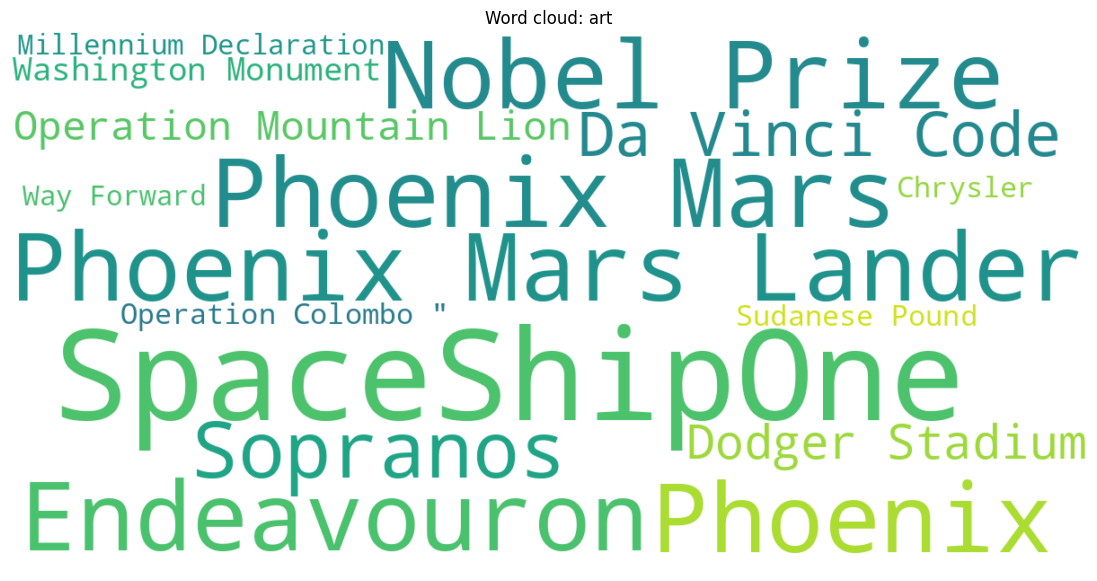

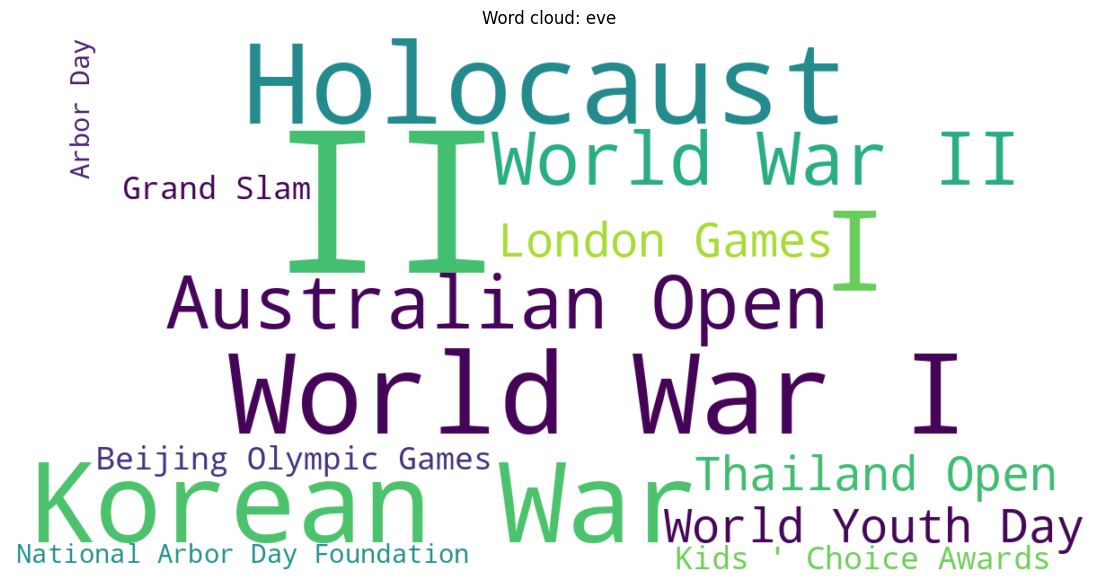

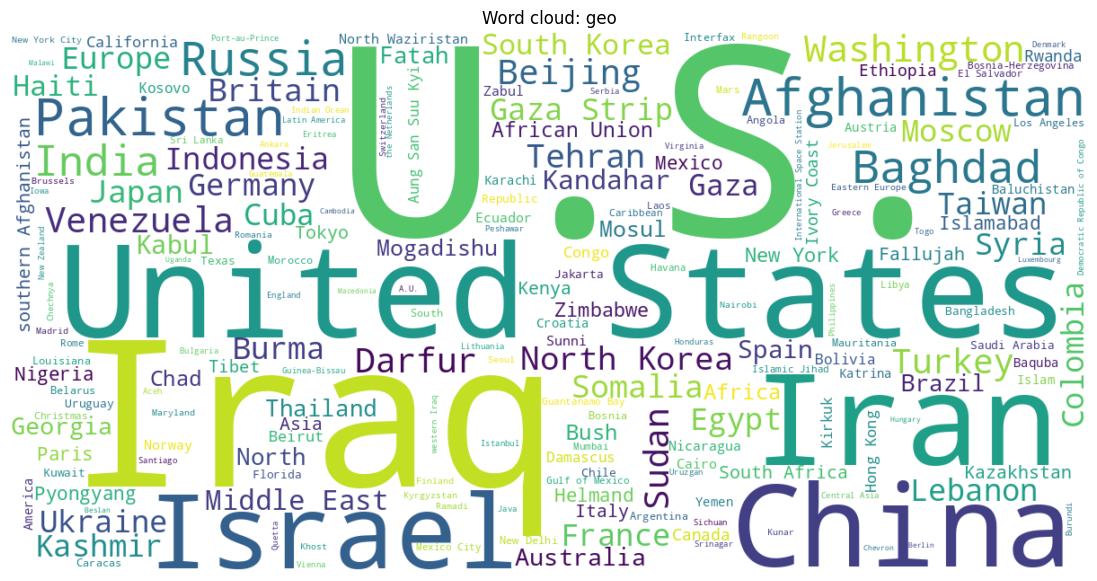

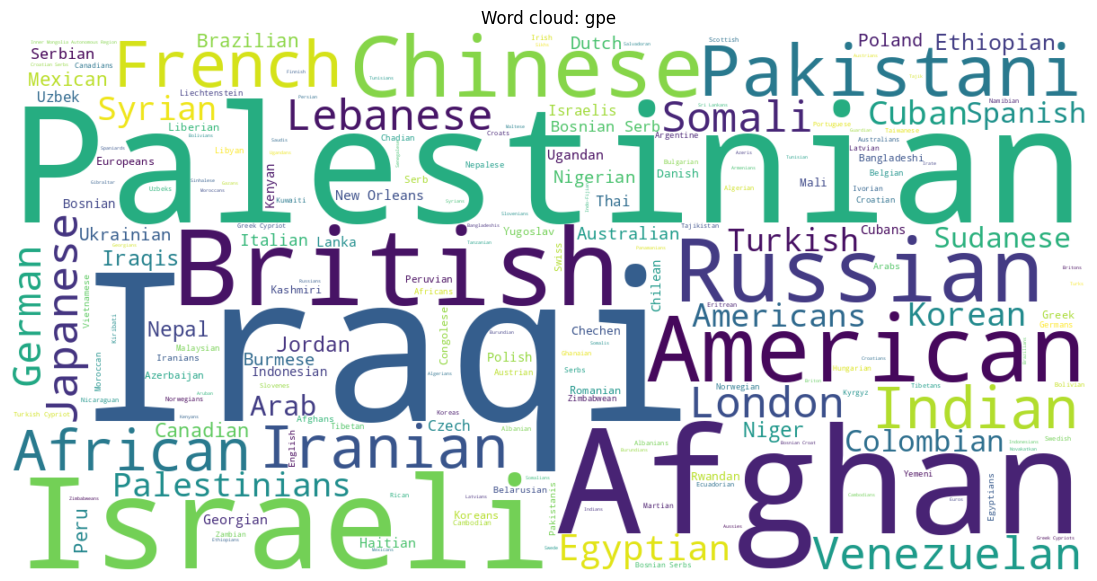

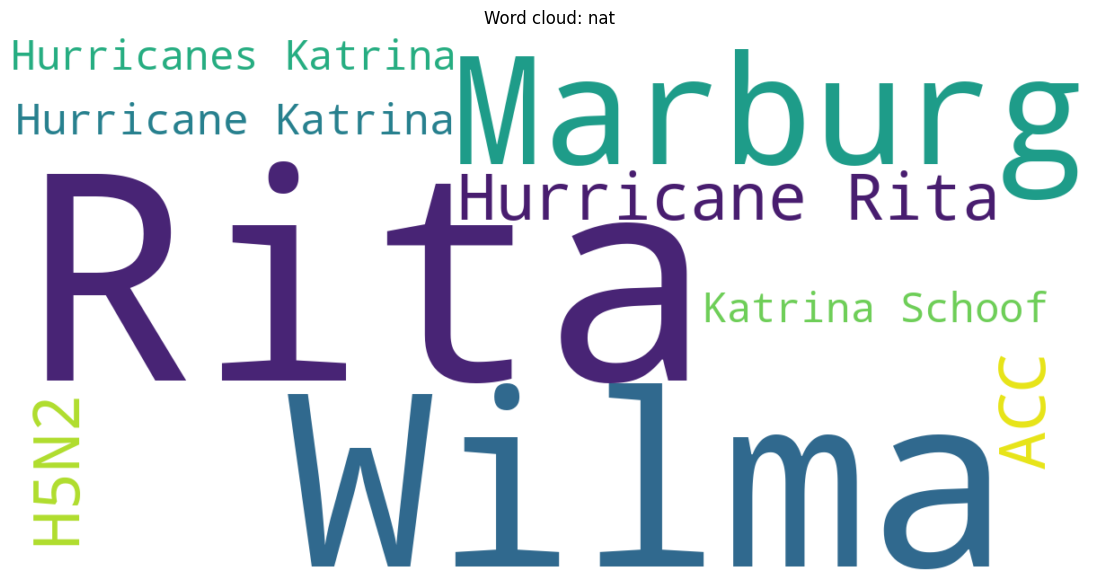

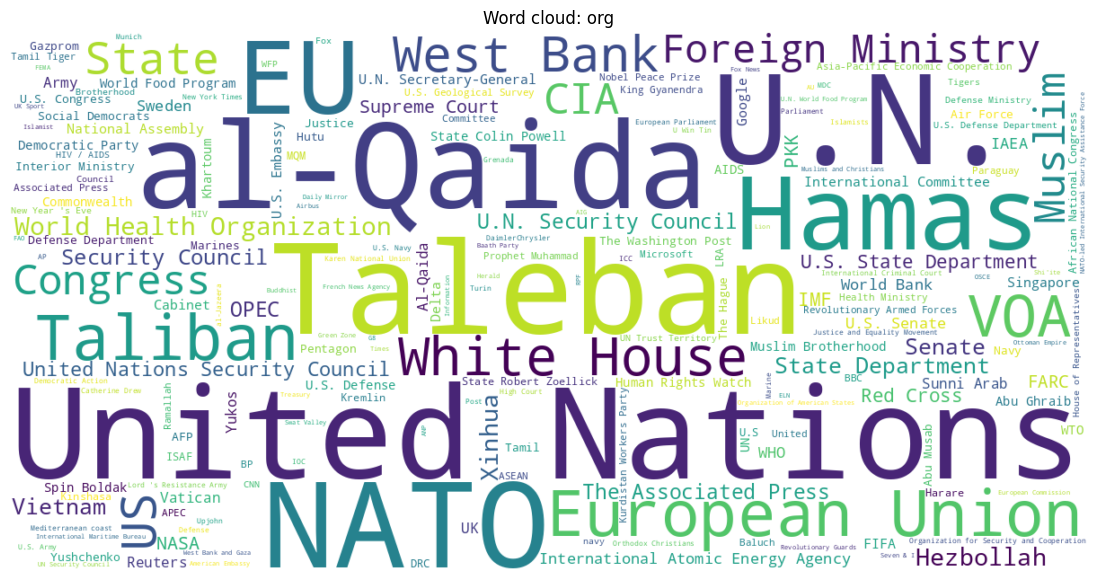

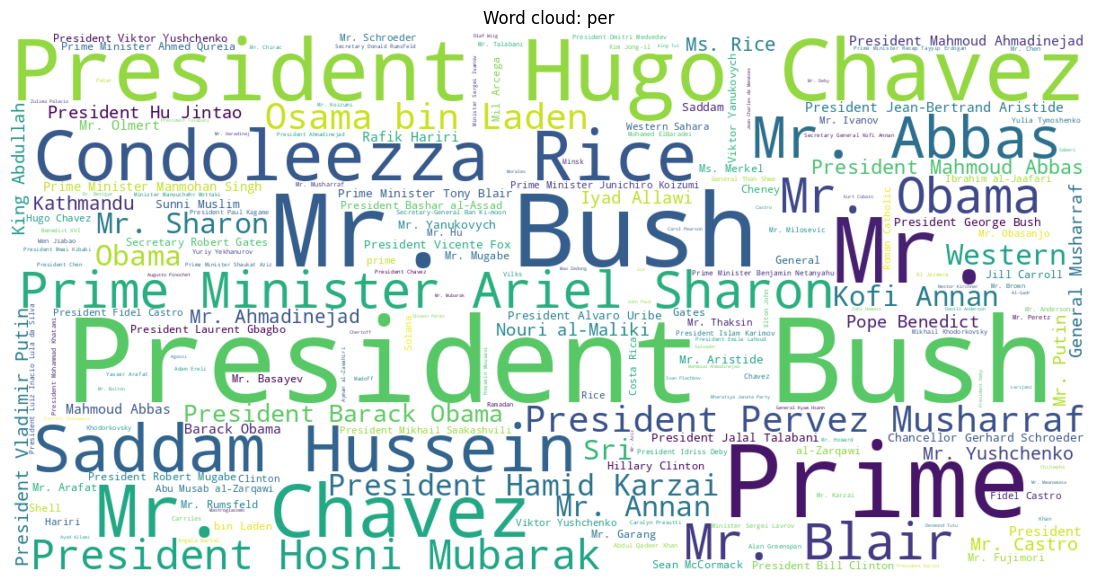

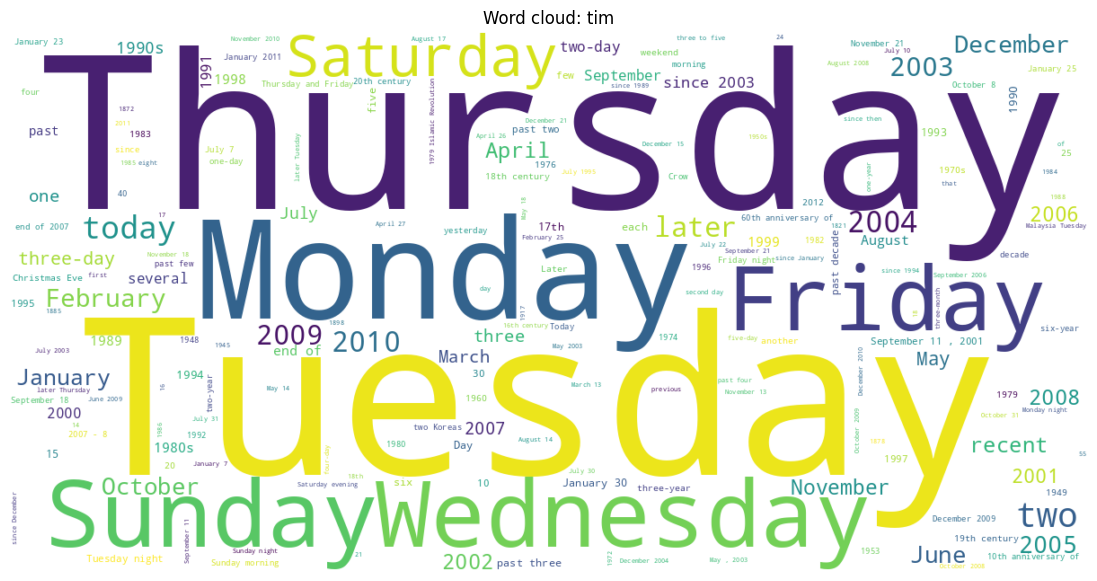

In [ ]:
for cat in sorted(store.categories):
    plot_category_wordcloud(
        store,
        cat,
        save_path=os.path.join(FIG_DIR, f"wordcloud_{cat}.png"),
    )

## Submission

Теперь предскажем ннаши значения на тесте и отправим их в систему.

In [32]:
test_pred = tf_model.predict(test_examples)

Transformer predict:   0%|          | 0/9592 [00:00<?, ?it/s]

In [33]:
def blend_predictions(tf_pred, crf_pred):
    return [
        choose_best_sentence_pred(tf_seq, crf_seq)
        for tf_seq, crf_seq in zip(tf_pred, crf_pred)
    ]

In [34]:
test_pred_tf = tf_model.predict(test_examples)
test_pred_crf = crf_model.predict(test_examples)
test_pred = blend_predictions(test_pred_tf, test_pred_crf)

Transformer predict:   0%|          | 0/9592 [00:00<?, ?it/s]

CRF predict features:   0%|          | 0/9592 [00:00<?, ?it/s]

In [35]:
rows = []
for ex, pred_tags in zip(test_examples, test_pred):
    if len(pred_tags) < len(ex.row_ids):
        pred_tags = pred_tags + ["O"] * (len(ex.row_ids) - len(pred_tags))
    elif len(pred_tags) > len(ex.row_ids):
        pred_tags = pred_tags[:len(ex.row_ids)]

    pred_ids = [TAG2ID[tag] for tag in pred_tags]
    for row_id, pred_id in zip(ex.row_ids, pred_ids):
        rows.append({"ID": int(row_id), "TARGET": int(pred_id)})

submission = pd.DataFrame(rows).sort_values("ID").reset_index(drop=True)
submission.head()

,ID,TARGET
0,0,0
1,1,0
2,2,0
3,3,0
4,4,0


In [36]:
bad = []
for i, (ex, pred_tags) in enumerate(zip(test_examples, test_pred)):
    if len(ex.tokens) != len(pred_tags):
        bad.append((i, ex.sentence_id, len(ex.tokens), len(pred_tags)))

len(bad), bad[:10]

(0, [])

In [37]:
len(submission), len(test_df)

(209211, 209211)

In [38]:
submission_path = os.path.join(OUTPUT_DIR, "submission.csv")
submission.to_csv(submission_path, index=False)
submission_path

'/home/pavel/projects/mouse-learning/IAD25-ML-NLP-lab/outputs/submission.csv'